This dataset shows the annual circulation of materials at Toronto Public Library branches.

**Circulation** is defined as a combination of:
- first-time checkouts (i.e. when items are initially borrowed) and
- renewals (i.e. transactions that extend the due dates of borrowed items). 

This data covers the **circulation of physical materials** (e.g. books, CDs, DVDs, etc.) and electronic resources (e.g. ebooks, streaming content, etc.).

The branch associated with a circulation total is the library from which the transactions were processed.

For **online renewals** of physical materials, the circulation is associated with the home branch of the renewing customer.

The VIR (Virtual Library) branch code is used to represent all electronic circulation totals.

# 0. imports

In [1]:
import os
os.chdir("/home/ruchirich/Documents/repositories/toronto-open-data/tpl")
cwd = os.getcwd()
print(cwd)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_columns', None)

/home/ruchirich/Documents/repositories/toronto-open-data/tpl


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         1337 non-null   object
 1   BranchCode   1337 non-null   object
 2   Circulation  1337 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 31.5+ KB
None
   Year BranchCode  Circulation
0  2012         AB       515235
1  2012        ACD       446623
2  2012         AD       171050
3  2012         AG      1061437
4  2012         AH       204490


<Axes: xlabel='Year'>

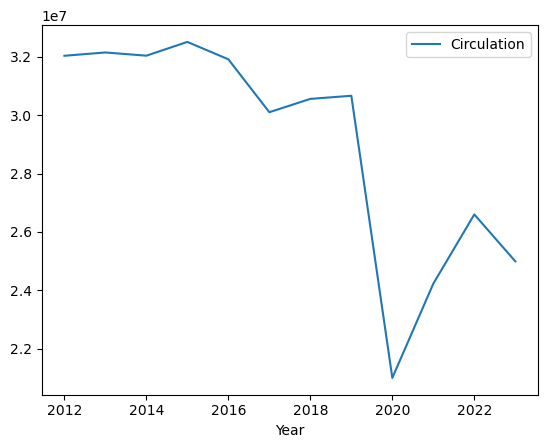

In [2]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-circulation"}
circulation_file = cwd+"/data/library-circulation.csv"

download_data(params, circulation_file)
usecols = ['Year', 'BranchCode', 'Circulation']
circulation = pd.read_csv(circulation_file, usecols=usecols, parse_dates=["Year"], date_format="%Y")
circulation['Year'] = circulation["Year"].dt.year.astype("object")
print(circulation.info())
print(circulation.head())

# Plot annual circulation at TPL
circulation[['Year', 'Circulation']].groupby('Year').sum().plot.line()

In [3]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-branch-general-information"}
branch_info_file = cwd+"/data/library-branch-general-information.csv"

download_data(params, branch_info_file)
# usecols = ["BranchCode", "BranchName", "PhysicalBranch"]
# branch_info = pd.read_csv(branch_info_file, usecols=usecols)
branch_info = pd.read_csv(branch_info_file)
print(branch_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   112 non-null    int64  
 1   BranchCode            112 non-null    object 
 2   PhysicalBranch        112 non-null    int64  
 3   BranchName            112 non-null    object 
 4   Address               103 non-null    object 
 5   PostalCode            103 non-null    object 
 6   Website               108 non-null    object 
 7   Telephone             105 non-null    object 
 8   SquareFootage         110 non-null    object 
 9   PublicParking         100 non-null    object 
 10  KidsStop              100 non-null    float64
 11  LeadingReading        100 non-null    float64
 12  CLC                   100 non-null    float64
 13  DIH                   100 non-null    float64
 14  TeenCouncil           100 non-null    float64
 15  YouthHub              1

## 0.1. data

In [4]:
# circulation_branch_info = pd.concat(objs=, axis=1, join="outer")
circulation_branch_info = circulation.merge(right=branch_info, indicator=True, left_on="BranchCode", right_on="BranchCode", how="left",validate="m:1")
print(circulation_branch_info.head())

   Year BranchCode  Circulation  _id  PhysicalBranch       BranchName  \
0  2012         AB       515235    1               1           Albion   
1  2012        ACD       446623    2               1  Albert Campbell   
2  2012         AD       171050    3               1        Alderwood   
3  2012         AG      1061437    4               1        Agincourt   
4  2012         AH       204490    5               1   Armour Heights   

                                     Address PostalCode  \
0     1515 Albion Road, Toronto, ON, M9V 1B2    M9V 1B2   
1  496 Birchmount Road, Toronto, ON, M1K 1N8    M1K 1N8   
2      2 Orianna Drive, Toronto, ON, M8W 4Y1    M8W 4Y1   
3     155 Bonis Avenue, Toronto, ON, M1T 3W6    M1T 3W6   
4     2140 Avenue Road, Toronto, ON, M5M 4M7    M5M 4M7   

                             Website     Telephone SquareFootage  \
0          https://www.tpl.ca/albion  416-394-5170         29000   
1  https://www.tpl.ca/albertcampbell  416-396-8890         28957   
2 

In [5]:
circulation_branch_info.to_csv(path_or_buf="data/data_binary_classification.csv", index=False)

# 1. PhysicalBranch (Online vs. Physical)

In [6]:
circulation_by_physical_branch = circulation_branch_info[["Year", "PhysicalBranch", "Circulation"]].pivot_table(index="Year", columns="PhysicalBranch", values="Circulation", aggfunc="sum")
circulation_by_physical_branch

PhysicalBranch,0,1
Year,,
2012,2286434,29745602
2013,3282100,28862921
2014,4558325,27476470
2015,5425634,27080329
2016,6013845,25896732
2017,6496530,23602360
2018,7802315,22753255
2019,8761042,21900991
2020,10773531,10227385


In [7]:
circulation_by_physical_branch_melted = circulation_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Circulation")

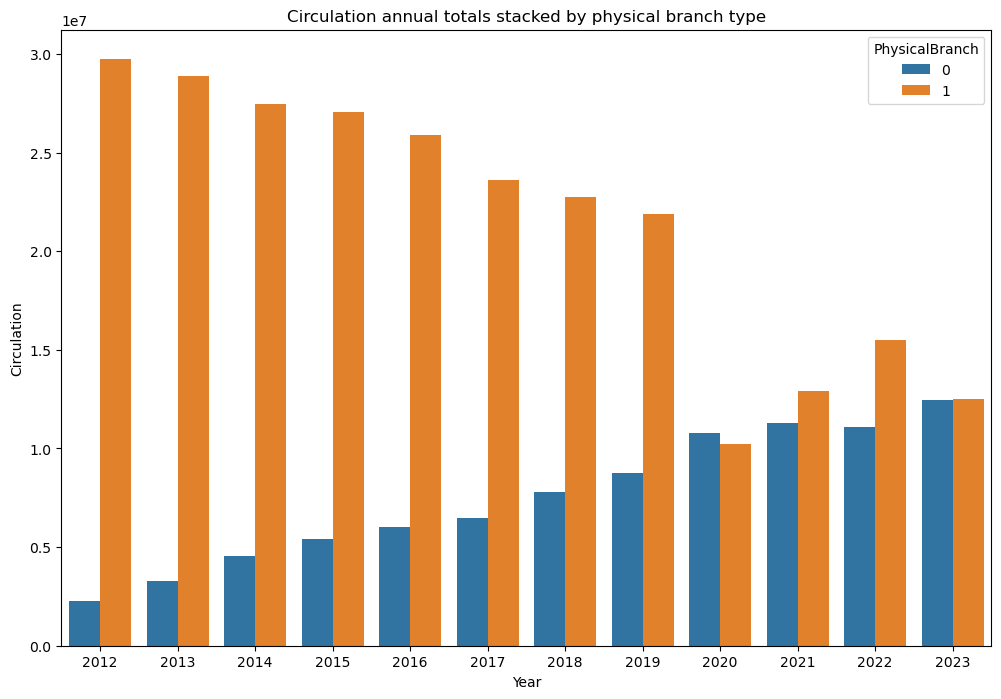

In [8]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=circulation_by_physical_branch_melted,
    x="Year",
    y="Circulation",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Circulation annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="Circulation",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/annual_circulation_by_physical_branch_indicator.png")

In [9]:
circulation_by_physical_branch_pct = circulation_by_physical_branch.copy(deep=True)
circulation_by_physical_branch_pct[0] = circulation_by_physical_branch_pct[0] / (circulation_by_physical_branch_pct[0] + circulation_by_physical_branch_pct[1]) * 100
circulation_by_physical_branch_pct[1] = circulation_by_physical_branch_pct[1] / (circulation_by_physical_branch[0] + circulation_by_physical_branch_pct[1]) * 100
print(circulation_by_physical_branch_pct)

PhysicalBranch          0          1
Year                                
2012             7.137960  92.862040
2013            10.210290  89.789710
2014            14.229293  85.770707
2015            16.691196  83.308804
2016            18.845930  81.154070
2017            21.583952  78.416048
2018            25.534837  74.465163
2019            28.572933  71.427067
2020            51.300291  48.699709
2021            46.599881  53.400119
2022            41.650029  58.349971
2023            49.910253  50.089747


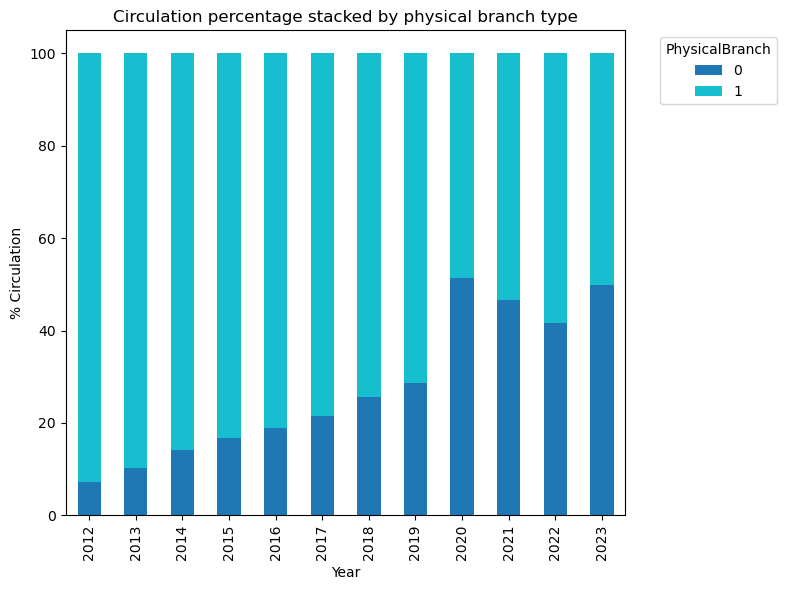

In [10]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
circulation_by_physical_branch_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set(
    title="Circulation percentage stacked by physical branch type",
    xlabel="Year",
    ylabel="% Circulation",
)
ax.legend(title='PhysicalBranch', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
fig.savefig(fname="output/annual_percentage_circulation_by_physical_branch_indicator.png")

## 1.0 Online Branch drilldown

In [11]:
online_circulation = circulation_branch_info[circulation_branch_info['PhysicalBranch'] == 0]
print(online_circulation.head())

    Year BranchCode  Circulation  _id  PhysicalBranch            BranchName  \
5   2012         AL        54585    6               0            Answerline   
13  2012      BKONE        67865   14               0        Bookmobile One   
14  2012      BKTWO        70889   15               0        Bookmobile Two   
30  2012         DS        10226   31               0    Departmental Staff   
47  2012        HLS       384444   49               0  Home Library Service   

   Address PostalCode                                  Website     Telephone  \
5      NaN        NaN               https://www.tpl.ca/contact  416-397-5981   
13     NaN        NaN           https://www.tpl.ca/bookmobiles           NaN   
14     NaN        NaN           https://www.tpl.ca/bookmobiles           NaN   
30     NaN        NaN                                      NaN           NaN   
47     NaN        NaN  https://www.tpl.ca/home-library-service  416-395-5557   

   SquareFootage PublicParking  KidsStop  Le

In [12]:
branch_stats = online_circulation.groupby(by='BranchCode').Circulation.describe()
branch_stats.sort_values(by='max', ascending=False)

,count,mean,std,min,25%,50%,75%,max
BranchCode,,,,,,,,
VIR,12.0,6.796927e+06,3.774083e+06,1073340.0,4168805.75,6320311.0,10604861.75,12313520.0
PR,12.0,2.961212e+05,1.894772e+05,55046.0,87069.50,313715.5,446344.75,570890.0
HLS,12.0,2.758987e+05,1.495307e+05,43669.0,107388.75,353029.0,388936.50,413186.0
BKTWO,12.0,3.001850e+04,2.206970e+04,6336.0,12235.00,26151.0,35871.50,71551.0
BKONE,12.0,3.968983e+04,1.784428e+04,13800.0,26173.50,36677.0,53614.25,67865.0
AL,12.0,3.928658e+04,1.594245e+04,13537.0,22112.25,46211.5,49814.50,56496.0
SB,12.0,2.843617e+04,1.813911e+04,2522.0,6897.50,37092.0,42756.50,46924.0
DS,12.0,8.234667e+03,2.817288e+03,5000.0,6100.25,7642.5,8774.75,14026.0
IL,12.0,3.969917e+03,1.417640e+03,885.0,4131.50,4359.5,4871.25,5076.0


## 1.1 Library Collections branches

Osborne and Merill Collections at Lilian H.Smith branch

In [13]:
branch_info[branch_info['BranchCode'] == 'OS']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
75,76,OS,0,Osborne Collection,"239 College Street, 4th floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/osborne,416-393-7753,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.65785,-79.39864,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
branch_info[branch_info['BranchCode'] == 'ME']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
67,68,ME,0,Merril Collection,"239 College Street, 3rd floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/merril,416-393-7748,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.657222,-79.398333,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2 AnswerLine

Feedback, Help and Customer Service

In [15]:
branch_info[branch_info['BranchCode'] == 'AL']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
5,6,AL,0,Answerline,NaN,NaN,https://www.tpl.ca/contact,416-397-5981,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year', ylabel='Circulation'>

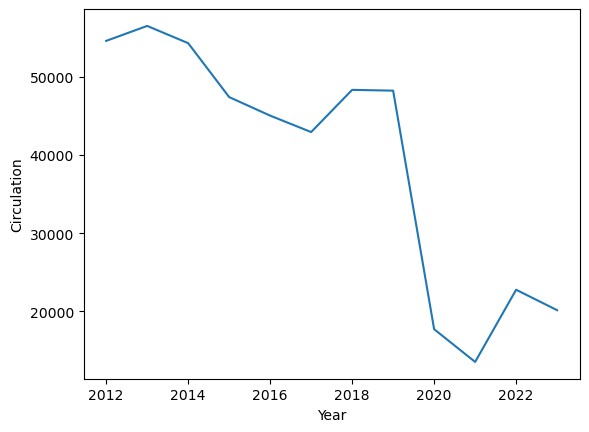

In [16]:
answerLine = online_circulation[online_circulation['BranchCode'] == 'AL']

sns.lineplot(data=answerLine, x='Year', y='Circulation')

## 1.3 Sunnybrook

The service provided supports the Sunnybrook community - its hospital patients, veterans and staff.

In [17]:
branch_info[branch_info['BranchCode'] == 'SB']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
91,92,SB,0,Sunnybrook Hospital,"2075 Bayview Avenue, Aging and Veterans Care, ...",M4N 3M5,https://www.tpl.ca/hospital-service,416-480-6100 EXT 62624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year', ylabel='Circulation'>

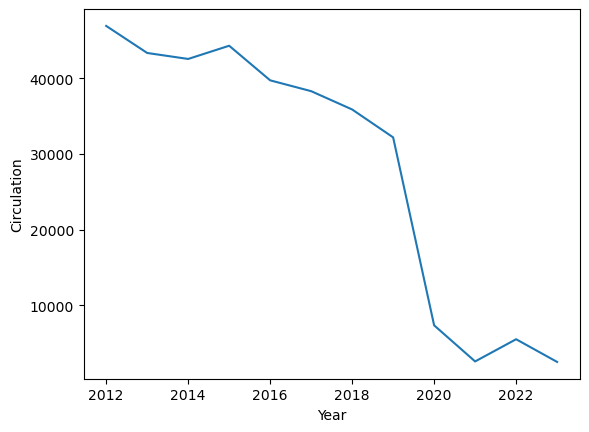

In [18]:
Sunnybrook = online_circulation[online_circulation['BranchCode'] == 'SB']

sns.lineplot(data=Sunnybrook, x='Year', y='Circulation')

# APPENDIX

## A.1 Correlation plot

Correlation of `Circulation` in `BranchCode` feature

In [19]:
circulation_by_branch = circulation.pivot(columns='BranchCode',index='Year',values='Circulation')
circulation_by_branch = circulation_by_branch.dropna()
circulation_correlation = circulation_by_branch.corr()

<Figure size 800x600 with 0 Axes>

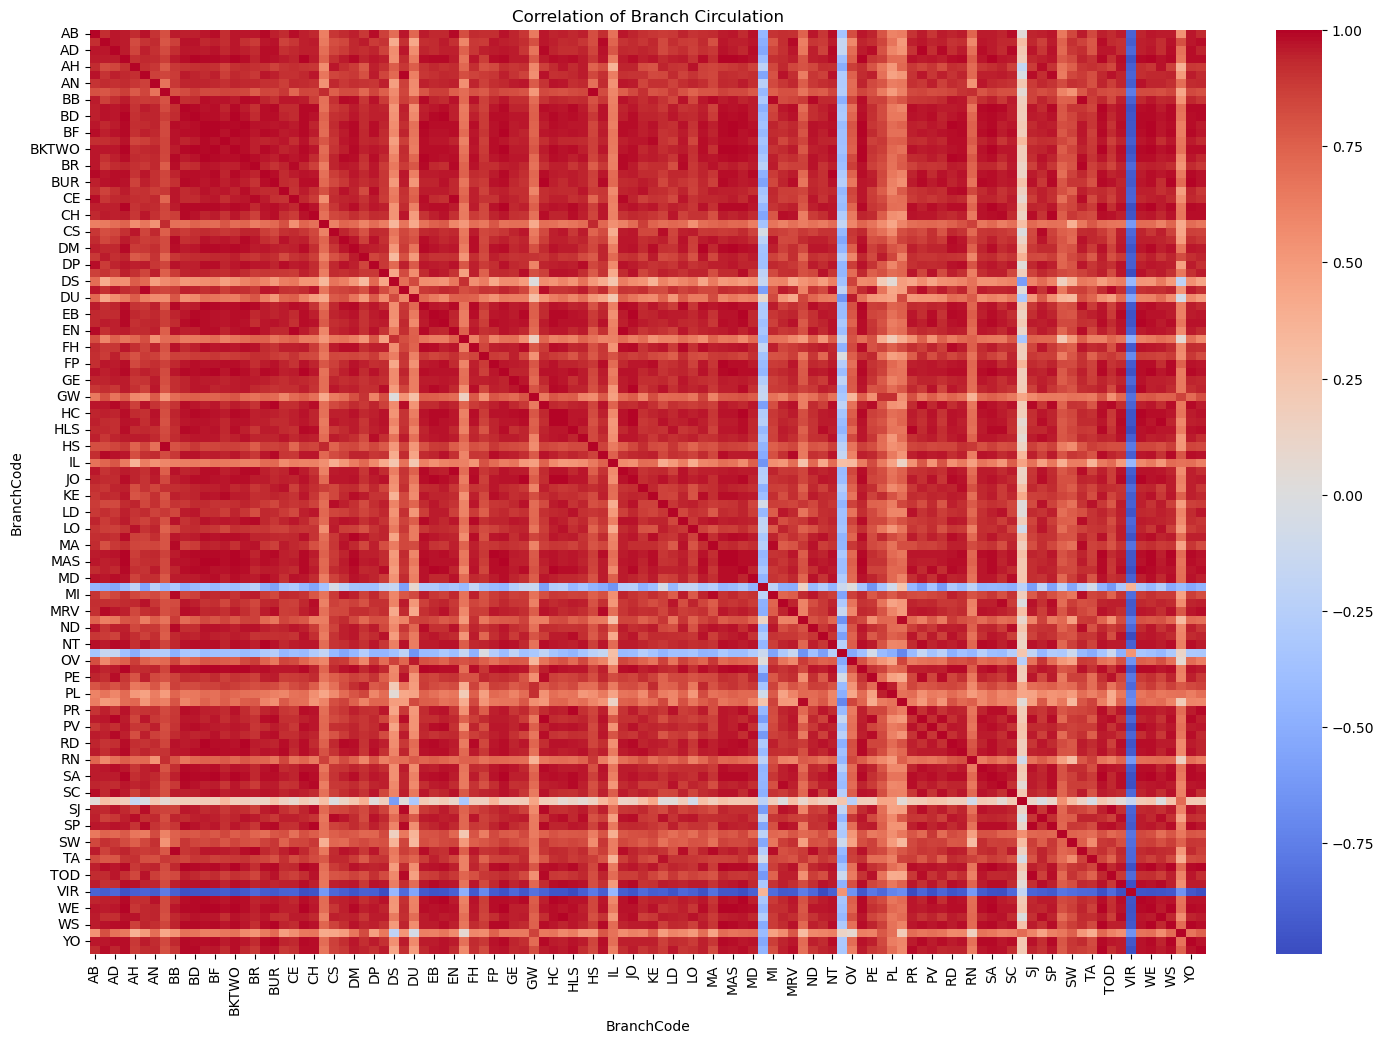

In [20]:
fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111)

plt.figure(figsize=(18,12))
heatmap = sns.heatmap(data=circulation_correlation,cmap='coolwarm')

heatmap.set(
    title="Correlation of Branch Circulation",
    xlabel="BranchCode",
    ylabel="BranchCode",
)
# heatmap.xaxis.set_ticklabels([])
# heatmap.yaxis.set_ticklabels([])

# plt.show()
fig.savefig(fname="output/Branch_Circulation_Correlation.png")

## A.2 PCA

Single Valued Decomposition of `BranchCode` feature across `Year` dimensions

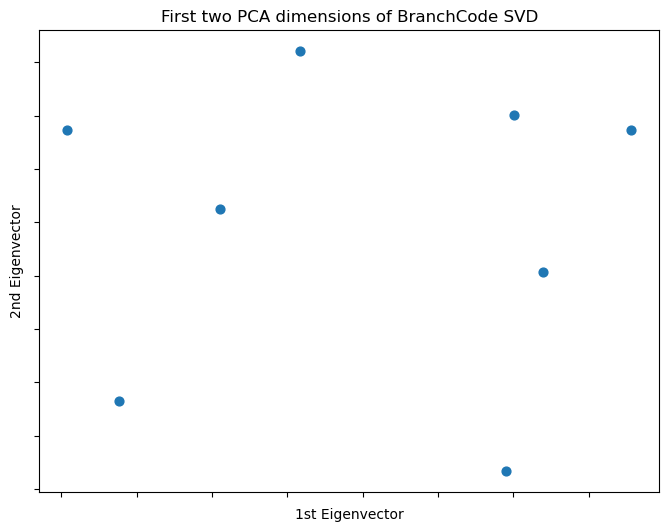

In [21]:
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111)
X_reduced = PCA(n_components=2).fit_transform(circulation_by_branch)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    s=40,
)

ax.set(
    title="First two PCA dimensions of BranchCode SVD",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

plt.show()
fig.savefig(fname="output/PCA_Circulation_2D.png")

In [22]:
X_reduced

array([[-3920767.38957133,   172983.35742342],
       [-3232242.13746132,  -335316.95690875],
       [-1894609.7195103 ,    25378.5231774 ],
       [ -828896.88819849,   321421.92755601],
       [ 1908314.96506679,  -465439.68593253],
       [ 2395676.03066009,   -93466.42234137],
       [ 2007666.58483863,   201511.61032402],
       [ 3564858.55417594,   172927.64670181]])

In [23]:
X_reduced.shape

(8, 2)